In [1]:
import pandas as pd
import os.path

In [2]:
run_basename = '20260928_ParTauDETR_120epochs_softKinStopGrad'

obj_cls_trsh = 0.5
obj_cls_trsh_str = f'{obj_cls_trsh:.3f}'.replace('.', 'p')

df = pd.read_parquet(os.path.expanduser(f'~/tmp/{run_basename}-model_best-{obj_cls_trsh_str}thr.parquet'))

In [3]:
df.head()

,reco_jet_p4,gen_jet_p4,reco_cand_p4s,reco_cand_pdgs,reco_cand_charges,gen_jet_tau_vis_energy,gen_jet_tau_decaymode,gen_jet_tau_charge,gen_jet_tau_full_p4,gen_jet_tau_vis_daughter_p4s,...,gen_jet_tau_vis_daughter_charges,gen_jet_tau_p4,file_id,event_id,pred_tau_daughter_p4s,pred_tau_daughter_charges,tau_decaymode,tau_p4,tau_charge,gen_jet_tau_decaymode_exp
0,"{'pt': 28.01141246226131, 'eta': 0.62594993037...","{'pt': 28.153107903361537, 'eta': 0.6261941075...","[{'pt': 5.355902671813965, 'eta': 0.5888699293...","[211, 211, 211]","[1.0, -1.0, -1.0]",33.873270,10,-1.0,"{'pt': 38.03519545080289, 'eta': 0.62177128643...","[{'pt': 11.50993178607006, 'eta': 0.6079446722...",...,"[-1.0, -1.0, 1.0]","{'pt': 28.153107903361537, 'eta': 0.6261941075...",707419,30,"[{'x': 2.888611078262329, 'y': -10.12395477294...","[-1, 1, -1]",10,"{'rho': 26.194276809692383, 'phi': -1.29173743...",-1,10
1,"{'pt': 33.711961466283675, 'eta': 0.0561190190...","{'pt': 37.870262860551556, 'eta': 0.0393549506...","[{'pt': 6.542594909667969, 'eta': 0.0129832811...","[211, 211, 130, 130, 130, 22]","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0]",37.740174,11,1.0,"{'pt': 44.47542908044899, 'eta': 0.02974934168...","[{'pt': 1.7280236876430668, 'eta': 0.080435231...",...,"[0.0, 1.0, 1.0, -1.0]","{'pt': 37.68743641302869, 'eta': 0.03986450361...",704131,58,"[{'x': -4.847829341888428, 'y': -6.86339712142...","[-1, 1, 1]",10,"{'rho': 31.02179718017578, 'phi': -2.135236501...",1,11
2,"{'pt': 21.47006164302517, 'eta': 0.80450264946...","{'pt': 20.453849993411996, 'eta': 0.8044986719...","[{'pt': 3.5935041904449463, 'eta': 0.843456387...","[211, 130, 22, 22]","[-1.0, 0.0, 0.0, 0.0]",27.449100,1,-1.0,"{'pt': 33.02779795963855, 'eta': 0.82659275463...","[{'pt': 16.89733243315867, 'eta': 0.7958298258...",...,"[0.0, -1.0]","{'pt': 20.453852527257066, 'eta': 0.8044986709...",700153,96,"[{'x': -3.7239792346954346, 'y': -0.4202892780...","[-1, 0]",1,"{'rho': 18.989398956298828, 'phi': -2.99136638...",-1,1
3,"{'pt': 18.61034503407158, 'eta': -0.4895068962...","{'pt': 18.13051461595269, 'eta': -0.4886871005...","[{'pt': 13.610233306884766, 'eta': -0.51128113...","[211, 22, 22]","[-1.0, 0.0, 0.0]",20.353977,1,-1.0,"{'pt': 39.9830573215418, 'eta': -0.52251526831...","[{'pt': 4.507004933011936, 'eta': -0.419670486...",...,"[0.0, -1.0]","{'pt': 18.130517652478378, 'eta': -0.488687089...",701674,90,"[{'x': 2.2935943603515625, 'y': -11.5225772857...","[-1, 0]",1,"{'rho': 17.038488388061523, 'phi': -1.37620007...",-1,1
4,"{'pt': 0.33594428598124226, 'eta': -1.44753135...","{'pt': 0.3296147730742327, 'eta': -1.453719752...","[{'pt': 0.335944265127182, 'eta': -1.447531461...",[211],[-1.0],0.756709,0,-1.0,"{'pt': 13.797715577505697, 'eta': -1.775068965...","[{'pt': 0.3296147730742327, 'eta': -1.45371975...",...,[-1.0],"{'pt': 0.3296147730742327, 'eta': -1.453719752...",707294,3,"[{'x': -0.2147141844034195, 'y': 0.26707595586...",[-1],0,"{'rho': 0.34268316626548767, 'phi': 2.24793767...",-1,0


**TODO**: it's not clear why `gen_jet_tau_decaymode` and `gen_jet_tau_decaymode_exp` disagree in 0.21% of the cases.. We already have excluded Geant particles from the list of visible tau decay products.

In [4]:
sum(df['gen_jet_tau_decaymode'] != df['gen_jet_tau_decaymode_exp']) / sum(df['gen_jet_tau_decaymode'] == df['gen_jet_tau_decaymode_exp']) * 100

0.21678824059513618

Agreement in decay modes is not great. We can identify 90% of single pion decays as such, but only about half of the taus that we predict to be a single pion are in fact single pion.
In many single prong plus one or two neutral pions (DMs 1 and 2) decays, the single prong is misidentified as neutral, which is why most of them contribute to the "invalid" category.
The same holds true for 3-prong decays in which two of the three prongs are misidentified as neutral pions.

The main issue seems to be charge identification.

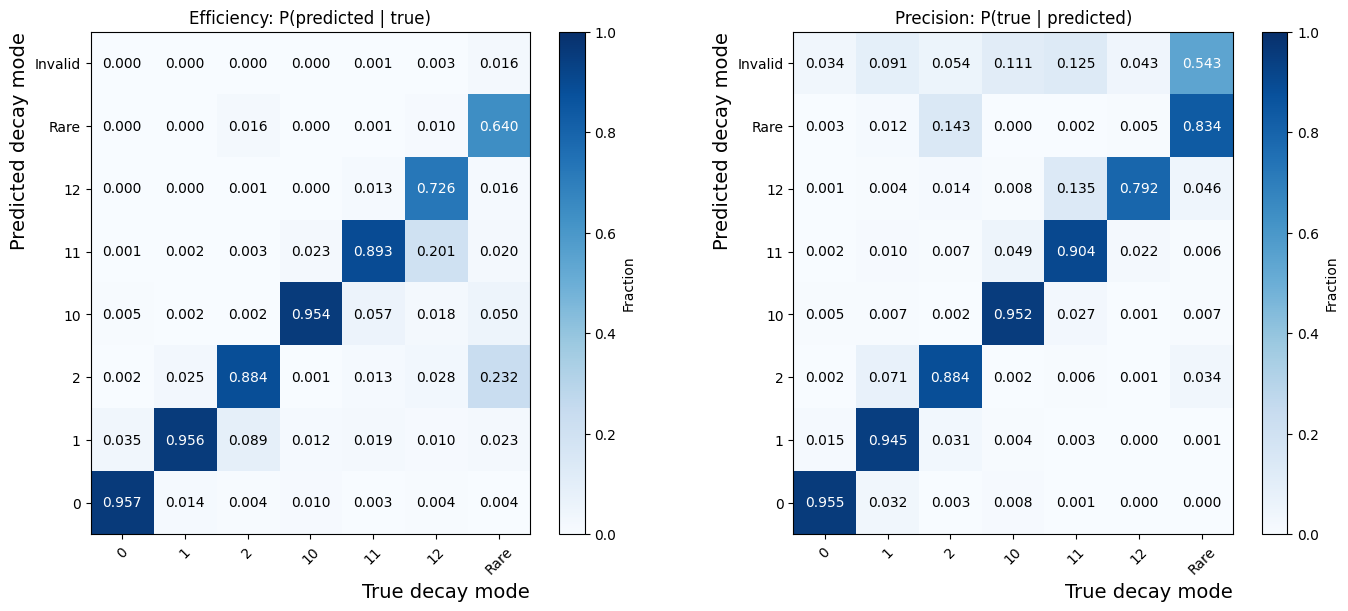

In [5]:
import matplotlib.pyplot as plt

explicit_dms = [0, 1, 2, 10, 11, 12]
labels = explicit_dms + ["Rare"]
predicted_labels = labels + ["Invalid"]


def normalize_truth_dm(dm):
    return dm if dm in explicit_dms else "Rare"


def predict_dm(charge_array):
    n_charged = sum(charge != 0 for charge in charge_array)
    n_neutral = sum(charge == 0 for charge in charge_array)
    if n_charged % 2 == 0 or n_neutral > 4:
        return "Invalid"
    dm = 5 * (n_charged - 1) + n_neutral
    return dm if dm in explicit_dms else "Rare"


true_dm = df["gen_jet_tau_decaymode"].map(normalize_truth_dm)
predicted_dm = df["pred_tau_daughter_charges"].map(predict_dm)

confusion_efficiency = pd.crosstab(
    predicted_dm,
    true_dm,
    normalize="columns",
).reindex(index=predicted_labels, columns=labels, fill_value=0).fillna(0)

confusion_precision = pd.crosstab(
    predicted_dm,
    true_dm,
    normalize="index",
).reindex(index=predicted_labels, columns=labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    ["Efficiency: P(predicted | true)", "Precision: P(true | predicted)"],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(labels)),
        xticklabels=labels,
        yticks=range(len(predicted_labels)),
        yticklabels=predicted_labels[::-1],
    )
    ax.set_xlabel("True decay mode", loc="right", fontsize=14)
    ax.set_ylabel("Predicted decay mode", loc="top", fontsize=14)
    ax.tick_params(axis="x", rotation=45)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")

plt.show()
plt.close()

The following plots confirm that the model is unable to predict the total charge correctly, as in close to half of the time the model predicts constituents whose charge sum equals zero.

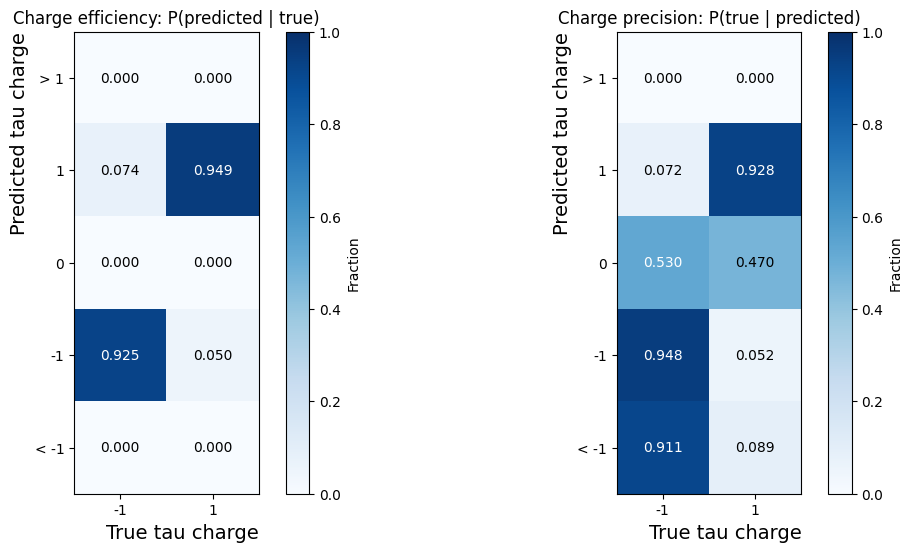

In [6]:
charge_labels = [-1, 1]
predicted_charge_labels = ["< -1", -1, 0, 1, "> 1"]


def predict_charge(charge_array):
    charge = sum(charge_array)
    if charge < -1:
        return "< -1"
    if charge > 1:
        return "> +1"
    return int(charge)


true_charge = df["gen_jet_tau_charge"].astype(int)
predicted_charge = df["pred_tau_daughter_charges"].map(predict_charge)
confusion_efficiency = pd.crosstab(
    predicted_charge,
    true_charge,
    normalize="columns",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)
confusion_precision = pd.crosstab(
    predicted_charge,
    true_charge,
    normalize="index",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=False,
    gridspec_kw={"wspace": 0},
)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    ["Charge efficiency: P(predicted | true)", "Charge precision: P(true | predicted)"],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(charge_labels)),
        xticklabels=charge_labels,
        yticks=range(len(predicted_charge_labels)),
        yticklabels=predicted_charge_labels[::-1],
    )
    ax.set_xlabel("True tau charge", loc="right", fontsize=14)
    ax.set_ylabel("Predicted tau charge", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")
plt.show()
plt.close()

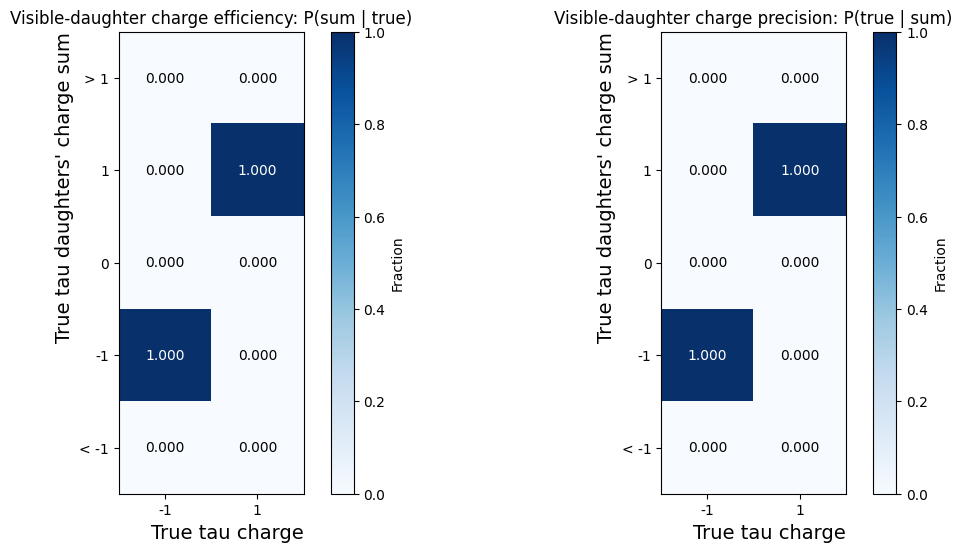

In [7]:
daughter_charge_labels = sorted(
    df["gen_jet_tau_vis_daughter_charges"].map(sum).astype(int).unique()
)


def sum_daughter_charge(charge_array):
    return int(sum(charge_array))


visible_daughter_charge = df["gen_jet_tau_vis_daughter_charges"].map(predict_charge)
confusion_efficiency = pd.crosstab(
    visible_daughter_charge,
    true_charge,
    normalize="columns",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)
confusion_precision = pd.crosstab(
    visible_daughter_charge,
    true_charge,
    normalize="index",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=False,
    gridspec_kw={"wspace": 0},
)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    [
        "Visible-daughter charge efficiency: P(sum | true)",
        "Visible-daughter charge precision: P(true | sum)",
    ],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(charge_labels)),
        xticklabels=charge_labels,
        yticks=range(len(predicted_charge_labels)),
        yticklabels=predicted_charge_labels[::-1],
    )
    ax.set_xlabel("True tau charge", loc="right", fontsize=14)
    ax.set_ylabel("True tau daughters' charge sum", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")
plt.show()
plt.close()

In negligible ($< 0.1\%$) subset of events the charge sum of generator-level tau daughters adds up to a value other than +1 or -1.

In [8]:
len(df[abs(df["gen_jet_tau_vis_daughter_charges"].map(sum_daughter_charge)) != 1]) / len(df) * 100

0.0

The model also tends to predict fewer objects than expected.

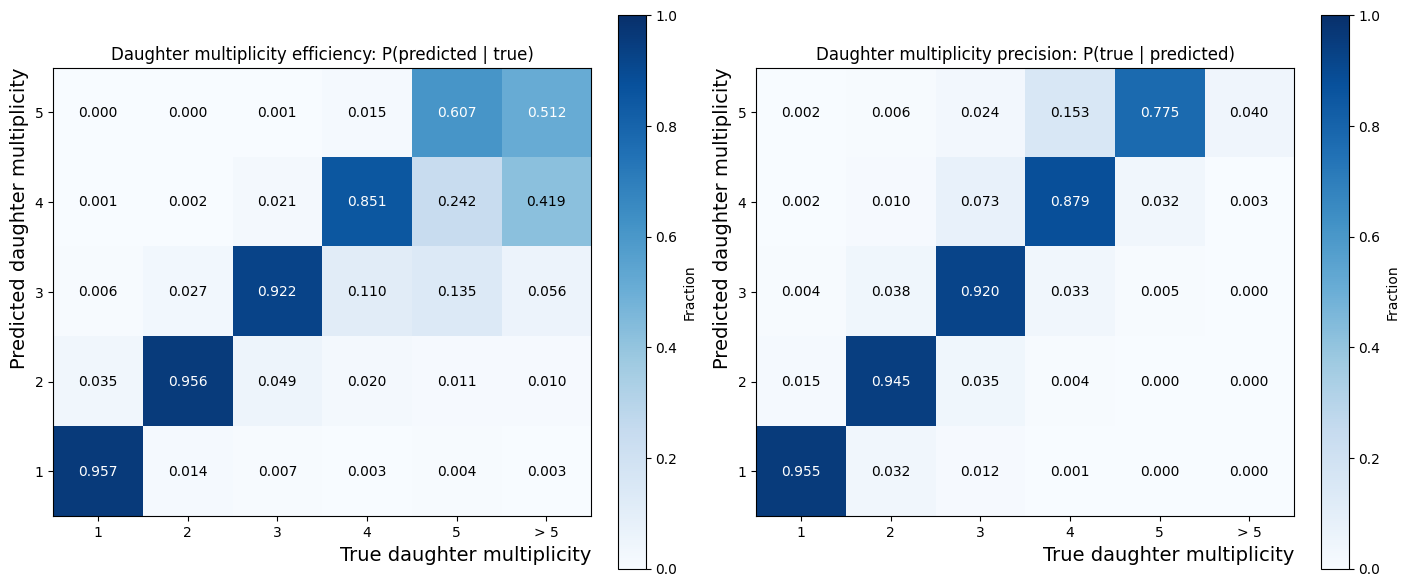

In [9]:
multiplicity_labels = [1, 2, 3, 4, 5, "> 5"]
predicted_multiplicity_labels = sorted(df["pred_tau_daughter_charges"].map(len).unique())


def normalize_true_multiplicity(multiplicity):
    return multiplicity if multiplicity <= 5 else "> 5"


true_multiplicity = df["gen_jet_tau_vis_daughter_pdgs"].map(len).map(
    normalize_true_multiplicity
)
predicted_multiplicity = df["pred_tau_daughter_charges"].map(len)
confusion_efficiency = pd.crosstab(
    predicted_multiplicity,
    true_multiplicity,
    normalize="columns",
).reindex(
    index=predicted_multiplicity_labels,
    columns=multiplicity_labels,
    fill_value=0,
).fillna(0)
confusion_precision = pd.crosstab(
    predicted_multiplicity,
    true_multiplicity,
    normalize="index",
).reindex(
    index=predicted_multiplicity_labels,
    columns=multiplicity_labels,
    fill_value=0,
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    [
        "Daughter multiplicity efficiency: P(predicted | true)",
        "Daughter multiplicity precision: P(true | predicted)",
    ],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(multiplicity_labels)),
        xticklabels=multiplicity_labels,
        yticks=range(len(predicted_multiplicity_labels)),
        yticklabels=predicted_multiplicity_labels[::-1],
    )
    ax.set_xlabel("True daughter multiplicity", loc="right", fontsize=14)
    ax.set_ylabel("Predicted daughter multiplicity", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction", shrink = 0.8)
plt.show()
plt.close()

In [10]:
import awkward as ak
import matplotlib as mpl
import numpy as np

n_events = -1
p4_sources = {
    "Generator visible tau": ("gen_jet_tau_p4", False),
    "Generator daughters": ("gen_jet_tau_vis_daughter_p4s", True),
    "Reconstructed jet": ("reco_jet_p4", False),
    "Reconstructed constituents": ("reco_cand_p4s", True),
    "Predicted daughters": ("pred_tau_daughter_p4s", True),
}
quantity_units = {"pt": "GeV", "eta": "", "phi": "", "mass": "GeV", "energy": "GeV"}
quantity_ranges = {
    "pt": (0, 45),
    "eta": (-2.7, 2.7),
    "phi": (-np.pi, np.pi),
    "mass": (0, 3),
    "energy": (0, 50),
}
n_bins = 32

def has_exactly_one_charged_pion(pdgs):
    return sum(abs(pdg) == 211 for pdg in pdgs) == 1

def is_predicted_single_pion(charges):
    return isinstance(charges, (list, tuple, np.ndarray)) and len(charges) == 1 and abs(charges[0]) == 1

one_charged_pion = df["gen_jet_tau_vis_daughter_pdgs"].map(has_exactly_one_charged_pion)
event_selections = {
    "Inclusive": None,
    "Generator one charged pion": one_charged_pion,
    "Generator one charged pion, predicted single pion": (
        one_charged_pion
        & df["pred_tau_daughter_charges"].map(is_predicted_single_pion)
    ),
}

def subset_events(series, event_mask=None):
    subset = series if n_events == -1 else series.iloc[:n_events]
    if event_mask is None:
        return subset
    return subset[event_mask.loc[subset.index]]

def p4_components(p4_array, predicted=False):
    if predicted:
        return (p4_array["x"], p4_array["y"], p4_array["z"], p4_array["t"])
    pt = p4_array["pt"]
    eta = p4_array["eta"]
    phi = p4_array["phi"]
    return (pt * np.cos(phi), pt * np.sin(phi), pt * np.sinh(eta), p4_array["energy"])

def summed_p4(p4_array, predicted=False):
    px, py, pz, energy = p4_components(p4_array, predicted=predicted)
    px = ak.sum(px, axis=1)
    py = ak.sum(py, axis=1)
    pz = ak.sum(pz, axis=1)
    energy = ak.sum(energy, axis=1)
    pt = np.hypot(px, py)
    eta = np.arcsinh(ak.where(pt != 0, pz / pt, 0))
    phi = np.arctan2(py, px)
    mass = np.sqrt(np.maximum(energy**2 - px**2 - py**2 - pz**2, 0))
    return {"pt": pt, "eta": eta, "phi": phi, "mass": mass, "energy": energy}

def histogram_with_uncertainty(values, bins):
    counts, _ = np.histogram(values, bins=bins)
    total = counts.sum()
    fractions = counts / total if total else np.zeros_like(counts, dtype=float)
    uncertainties = np.sqrt(counts) / total if total else np.zeros_like(counts, dtype=float)
    return fractions, uncertainties

def plot_quantity(quantity, event_mask=None, selection_label="Inclusive"):
    values = {
        name: source_quantity(field, quantity, is_array, event_mask)
        for name, (field, is_array) in p4_sources.items()
    }
    generator_values = values["Generator visible tau"]
    bins = np.linspace(*quantity_ranges[quantity], n_bins + 1)
    distributions = {}
    uncertainties = {}
    for name, source_values in values.items():
        distributions[name], uncertainties[name] = histogram_with_uncertainty(source_values, bins)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    source_colors = {
        name: colors[index % len(colors)]
        for index, name in enumerate(p4_sources)
    }
    centers = 0.5 * (bins[1:] + bins[:-1])

    for name in p4_sources:
        color = source_colors[name]
        axes[0].stairs(
            distributions[name], bins, label=name, linewidth=1.5, color=color
        )
        axes[0].errorbar(
            centers, distributions[name], yerr=uncertainties[name],
            fmt="none", capsize=2, alpha=0.5, color=color,
        )

    generator_distribution = distributions["Generator visible tau"]
    generator_uncertainty = uncertainties["Generator visible tau"]
    for name in list(p4_sources)[1:]:
        color = source_colors[name]
        source_distribution = distributions[name]
        ratio = np.divide(
            source_distribution,
            generator_distribution,
            out=np.full_like(generator_distribution, np.nan),
            where=generator_distribution > 0,
        )
        ratio_uncertainty = ratio * np.sqrt(
            np.divide(
                uncertainties[name] ** 2,
                source_distribution**2,
                out=np.zeros_like(ratio),
                where=source_distribution > 0,
            )
            + np.divide(
                generator_uncertainty**2,
                generator_distribution**2,
                out=np.zeros_like(ratio),
                where=generator_distribution > 0,
            )
        )
        axes[1].plot(
            centers, ratio, marker="o", markersize=3, label=name, color=color
        )
        axes[1].errorbar(
            centers, ratio, yerr=ratio_uncertainty,
            fmt="none", capsize=2, color=color,
        )

    for name in ["Reconstructed jet", "Predicted daughters"]:
        color = source_colors[name]
        relative_values = np.divide(
            values[name], generator_values,
            out=np.full_like(generator_values, np.nan, dtype=float),
            where=generator_values != 0,
        )
        mask = np.isfinite(relative_values)
        spread = []
        spread_uncertainty = []
        for lower_edge, upper_edge in zip(bins[:-1], bins[1:]):
            bin_values = relative_values[
                mask & (generator_values >= lower_edge) & (generator_values < upper_edge)
            ]
            if len(bin_values) < 2:
                spread.append(np.nan)
                spread_uncertainty.append(np.nan)
                continue
            median = np.median(bin_values)
            spread_value = (
                np.percentile(bin_values, 75) - np.percentile(bin_values, 25)
            ) / median
            spread.append(spread_value)
            spread_uncertainty.append(spread_value / np.sqrt(len(bin_values)))
        axes[2].plot(
            centers, spread, marker="o", markersize=3,
            label=name, color=color,
        )
        axes[2].errorbar(
            centers, spread, yerr=spread_uncertainty,
            fmt="none", capsize=2, color=color,
        )

    unit = f" [{quantity_units[quantity]}]" if quantity_units[quantity] else ""
    axes[0].set_title(f"{quantity} distribution")
    axes[1].set_title(f"{quantity} ratio to generator")
    axes[2].set_title(f"{quantity} relative spread")
    axes[0].set_ylabel(f"Normalized {quantity}{unit}")
    axes[1].set_ylabel("Ratio to generator")
    axes[2].set_ylabel("IQR / median")
    for ax in axes:
        ax.set_xlabel(f"Generator visible tau {quantity}{unit}")
        ax.grid(alpha=0.2)
    axes[1].axhline(1.0, color="black", linewidth=1, linestyle="--")
    for ax in axes:
        ax.legend(fontsize=8)
    for ax in axes:
        ax.set_xlim(bins[0], bins[-1])
    fig.suptitle(selection_label)
    plt.show()
    plt.close()

In [11]:
def source_quantity(field, quantity, is_array, event_mask=None):
    values = subset_events(df[field], event_mask)
    predicted = field == "pred_tau_daughter_p4s"
    if is_array:
        summed = summed_p4(ak.Array(values.tolist()), predicted=predicted)
        return np.asarray(ak.to_numpy(summed[quantity]))

    result = []
    for record in values:
        pt = float(record["pt"])
        eta = float(record["eta"])
        phi = float(record["phi"])
        if quantity == "mass":
            energy = float(record["energy"])
            value = np.sqrt(max(energy**2 - (pt * np.cosh(eta)) ** 2, 0.0))
        elif quantity == "energy":
            value = float(record["energy"])
        else:
            value = {"pt": pt, "eta": eta, "phi": phi}[quantity]
        result.append(value)
    return np.asarray(result)

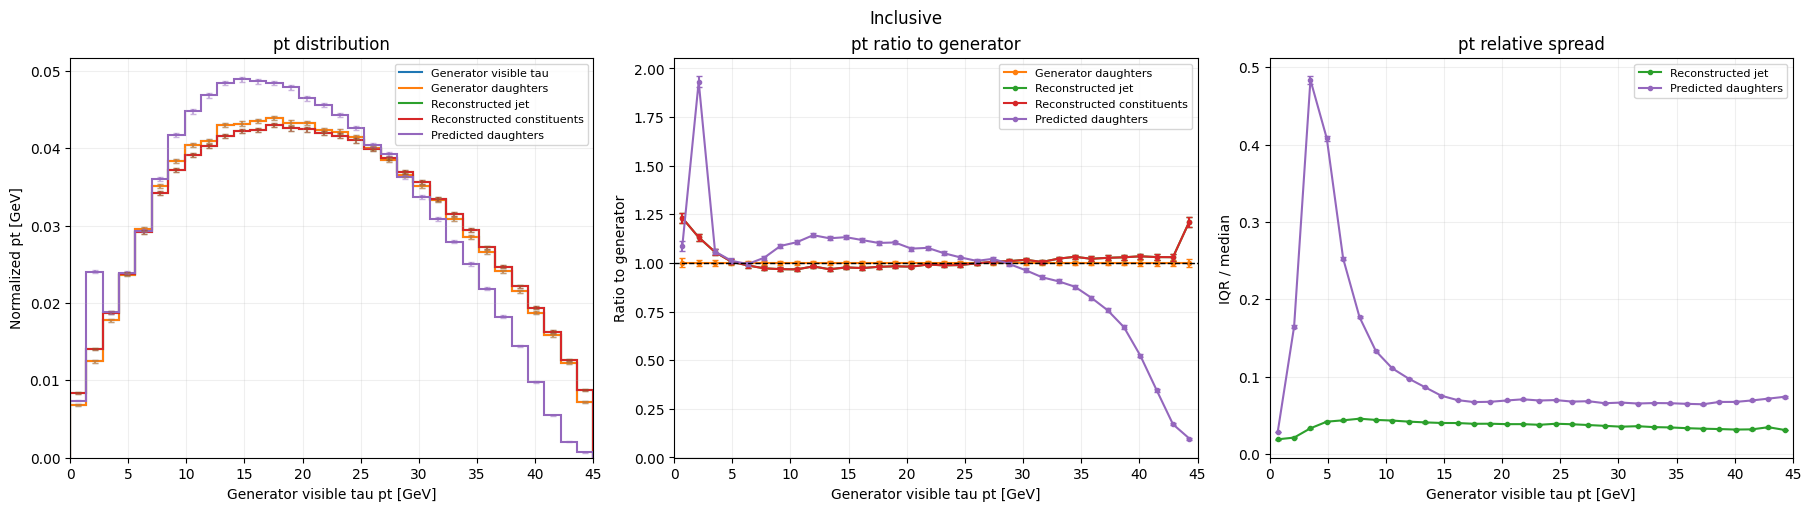

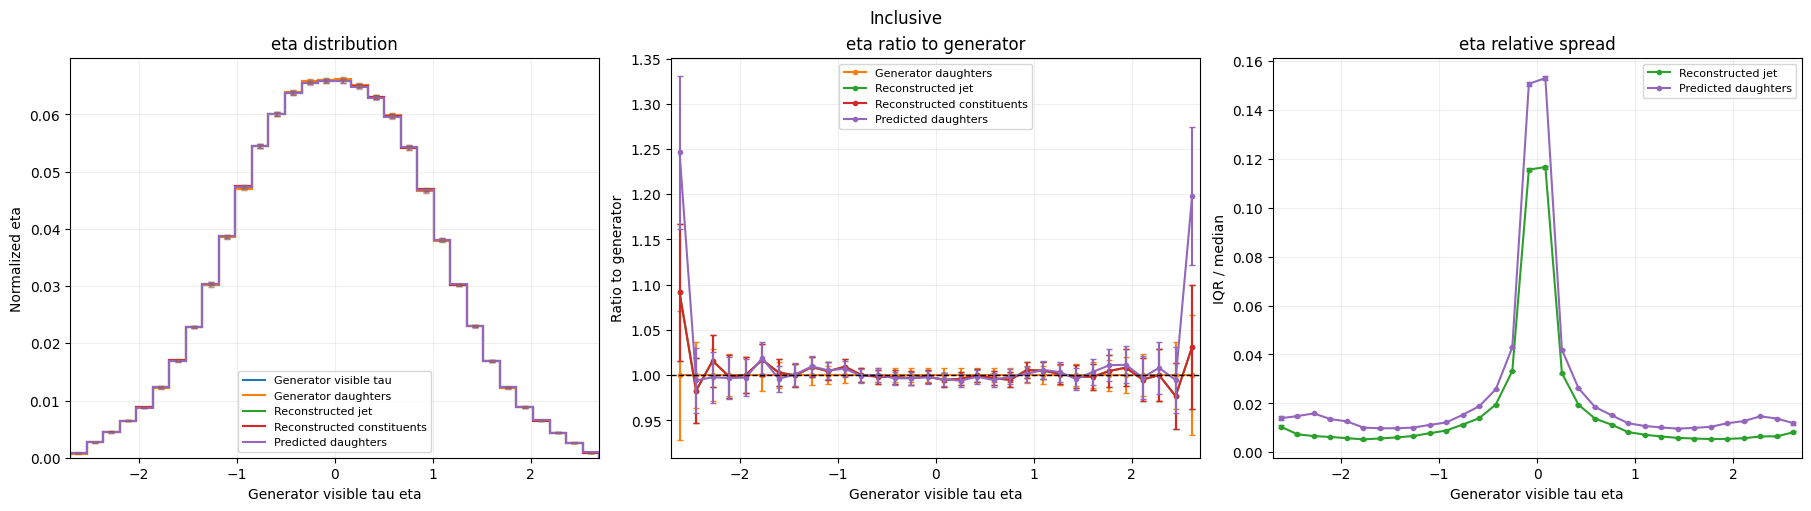

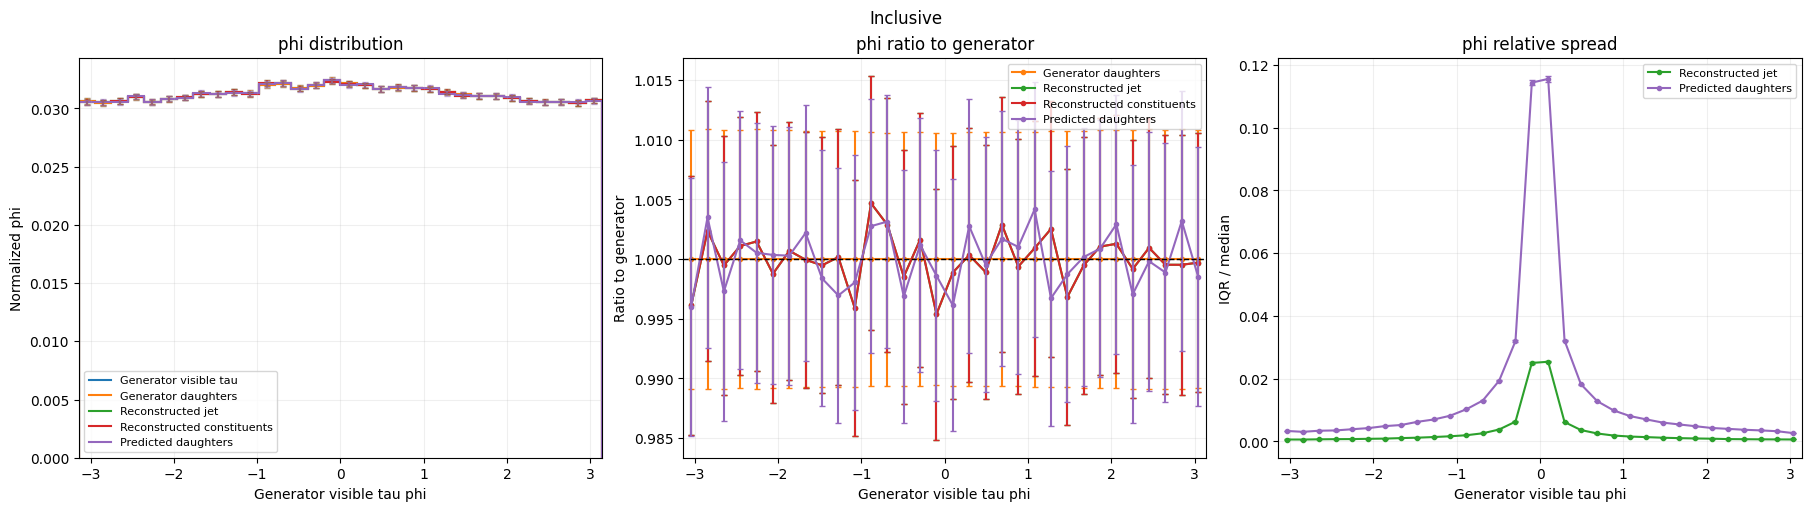

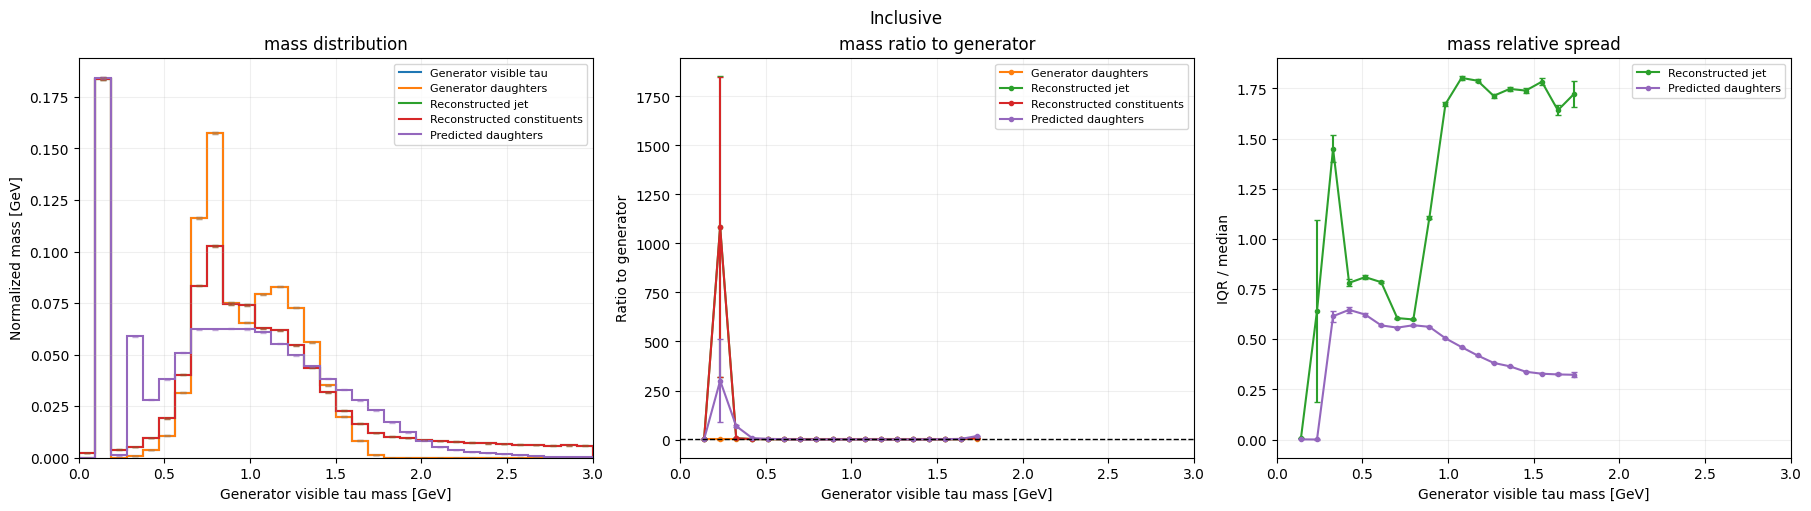

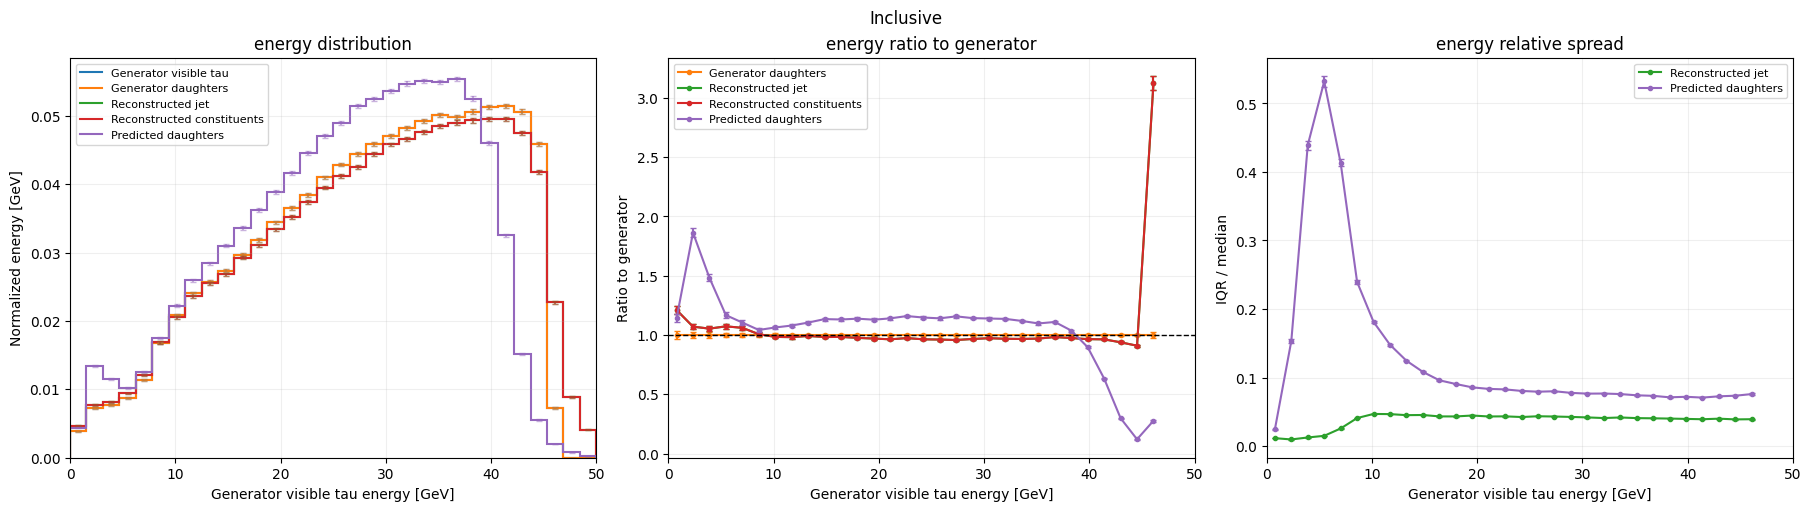

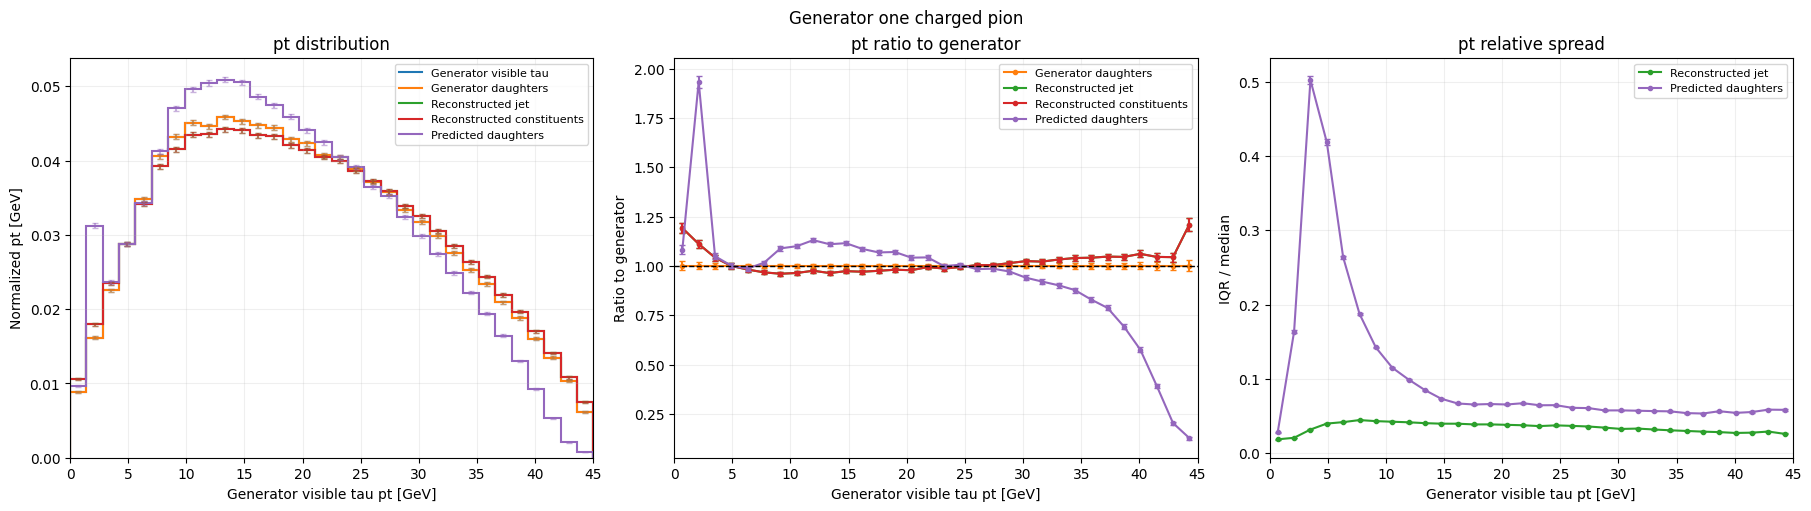

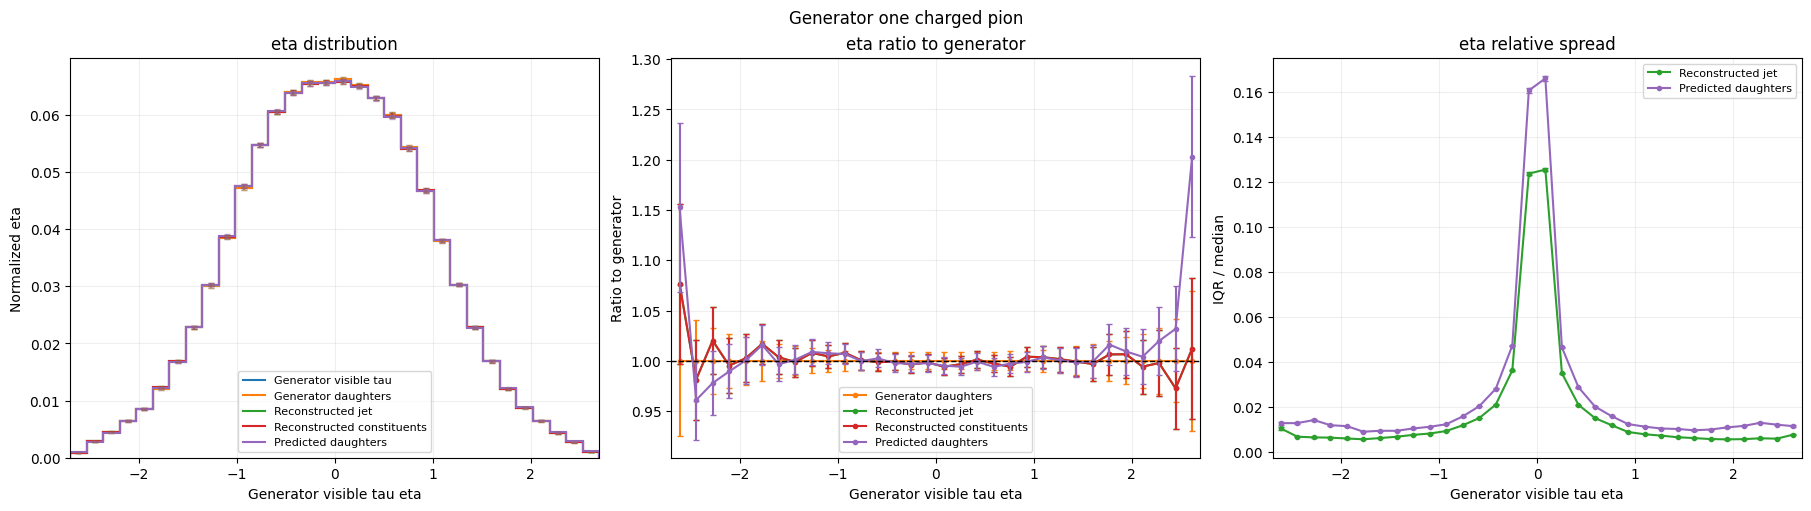

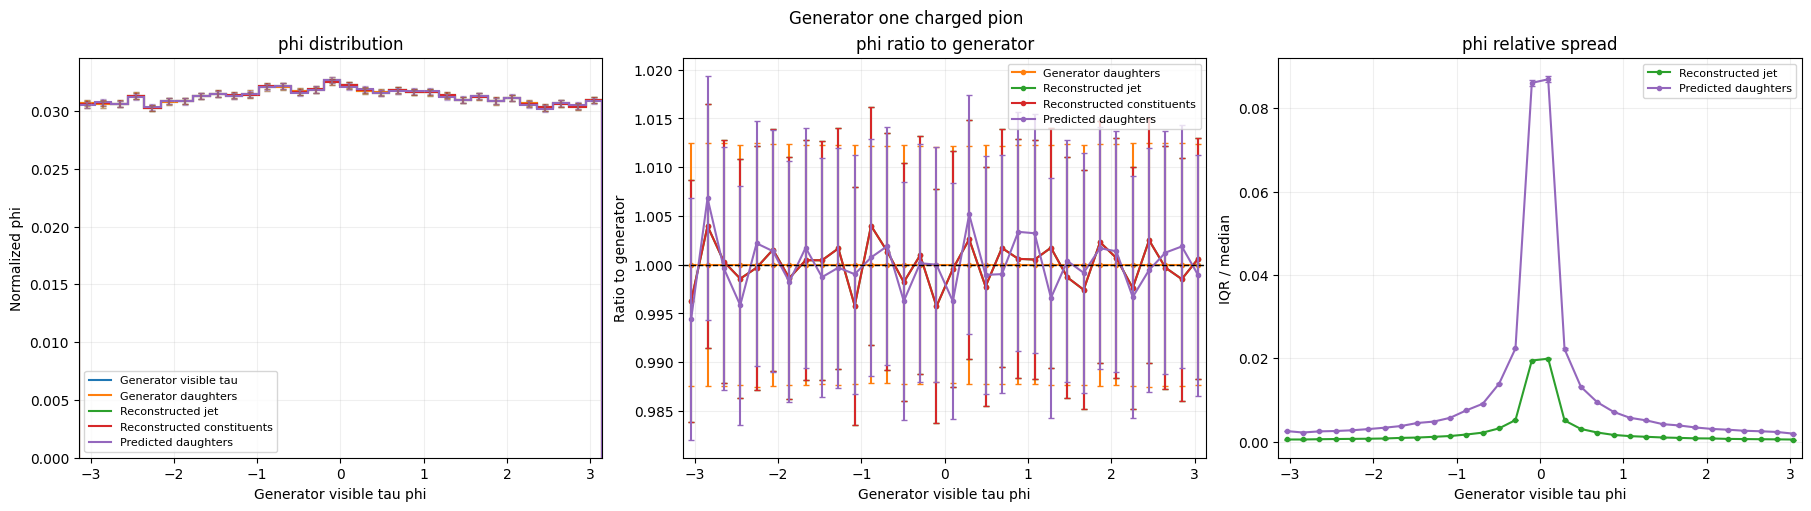

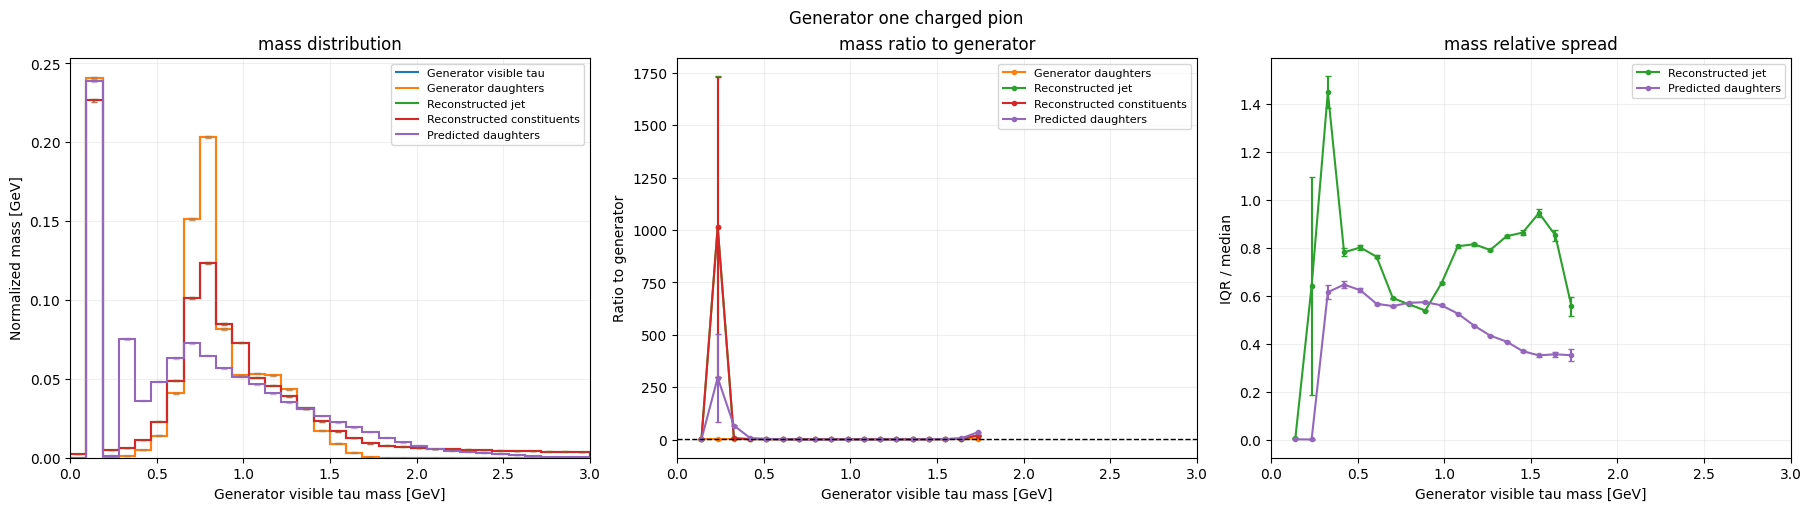

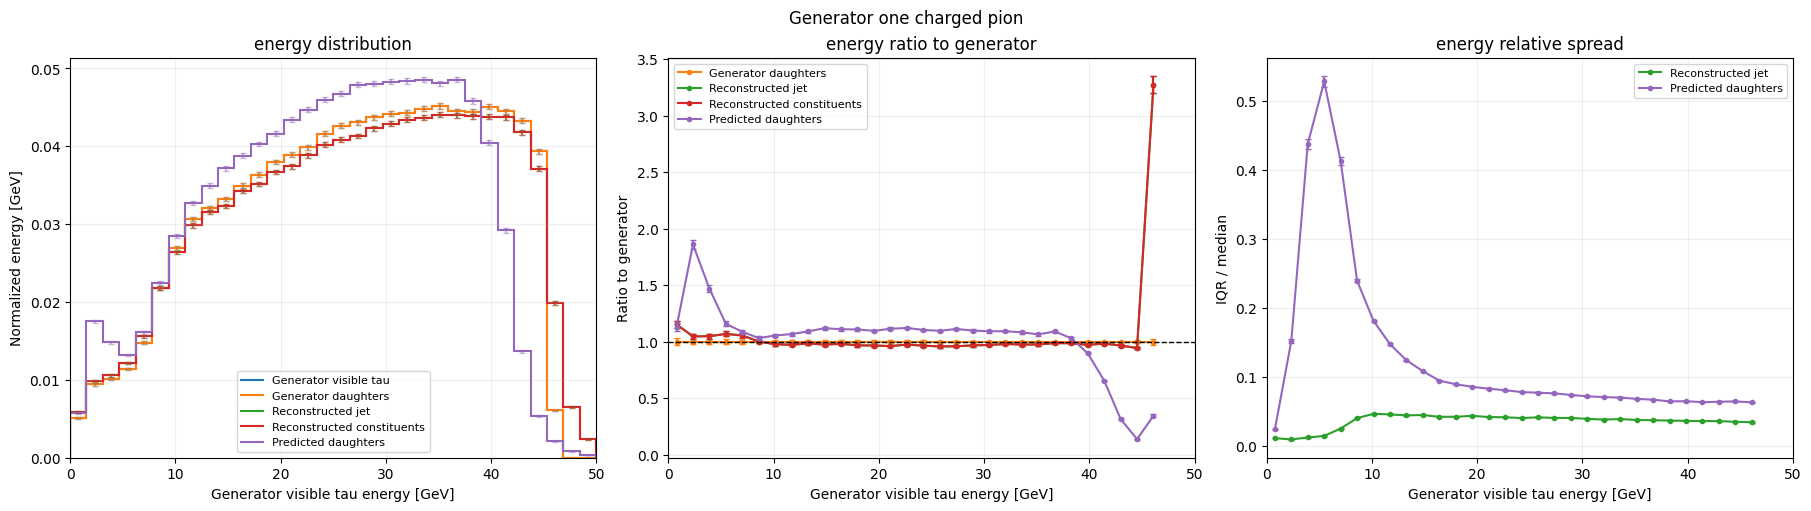

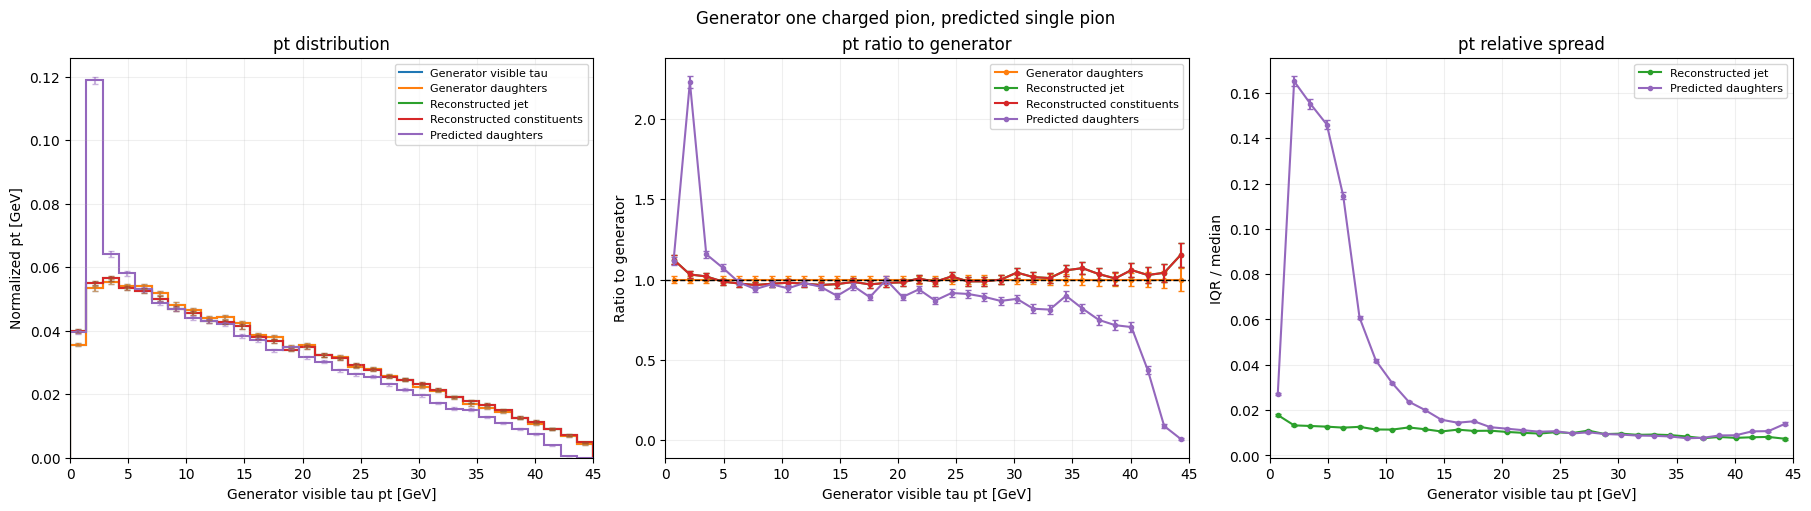

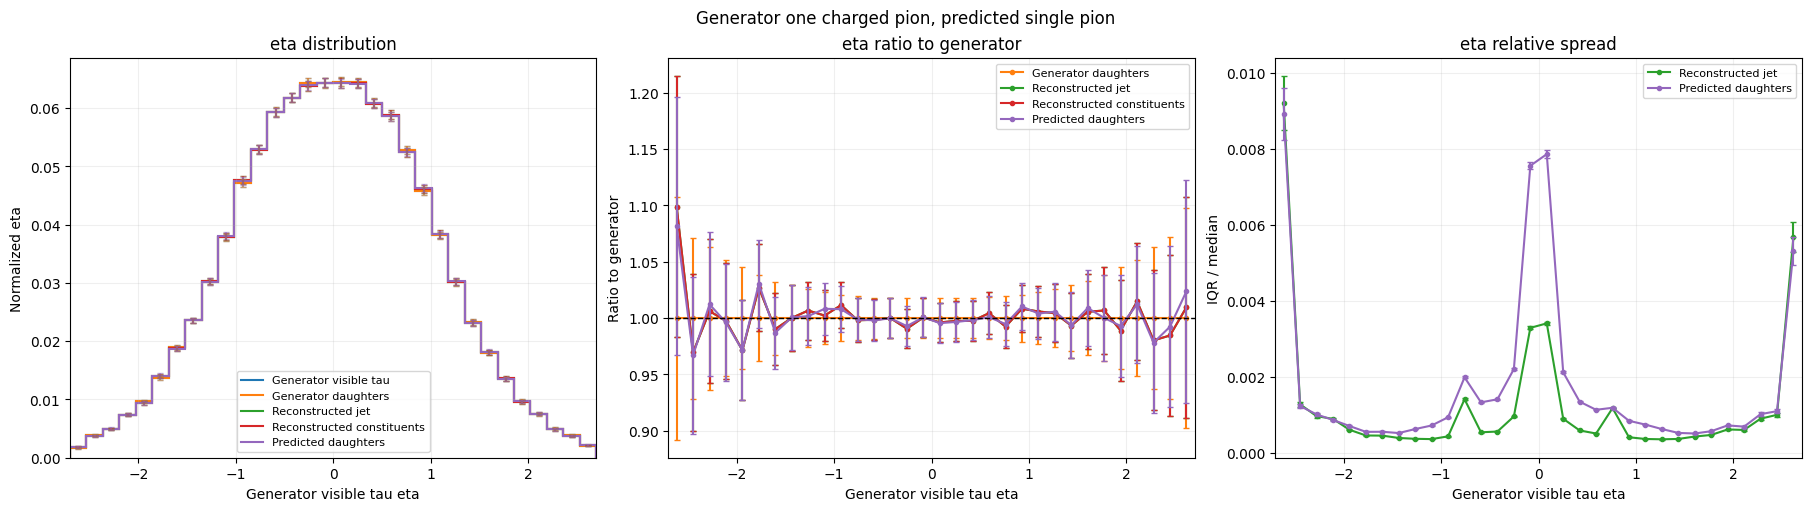

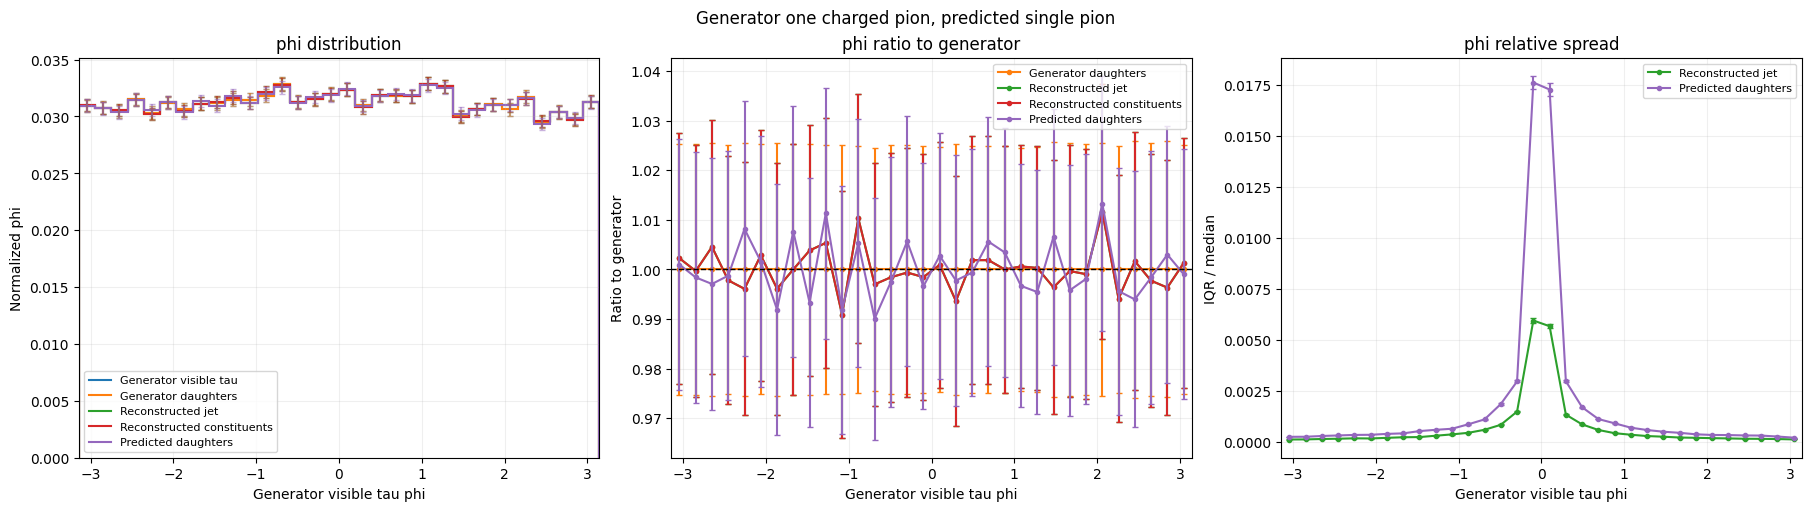

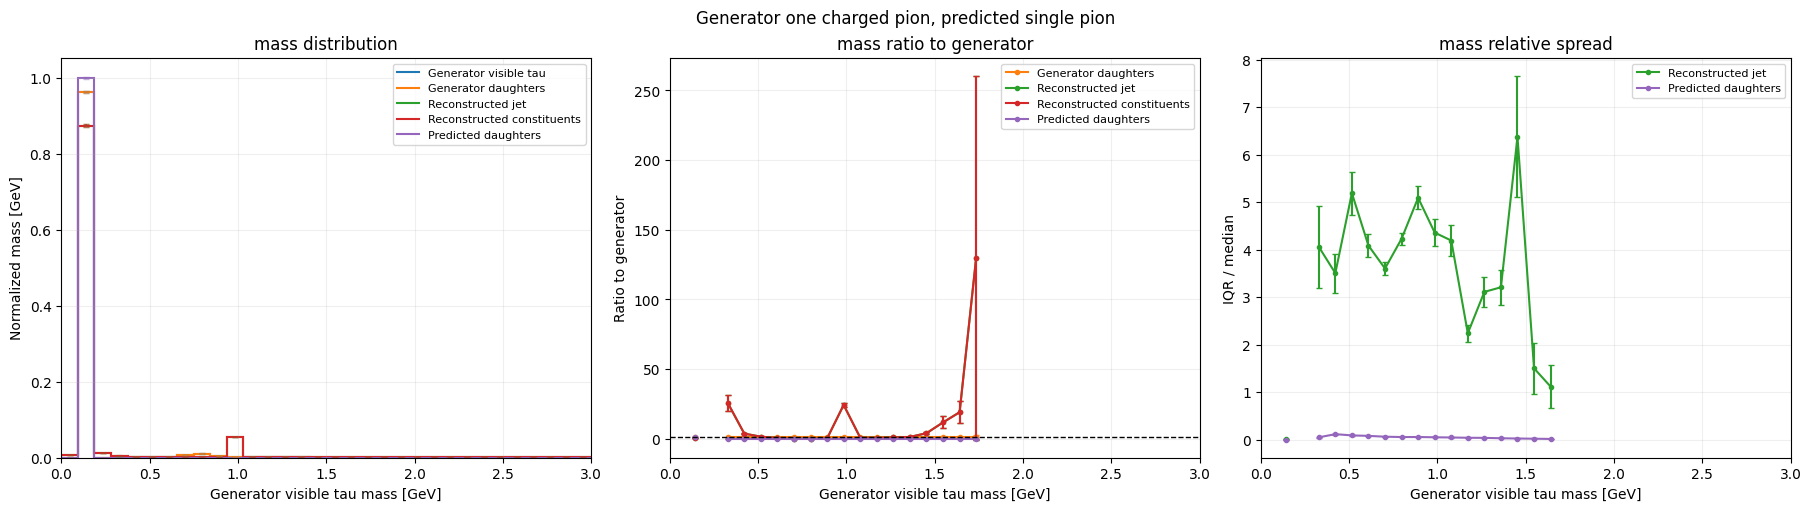

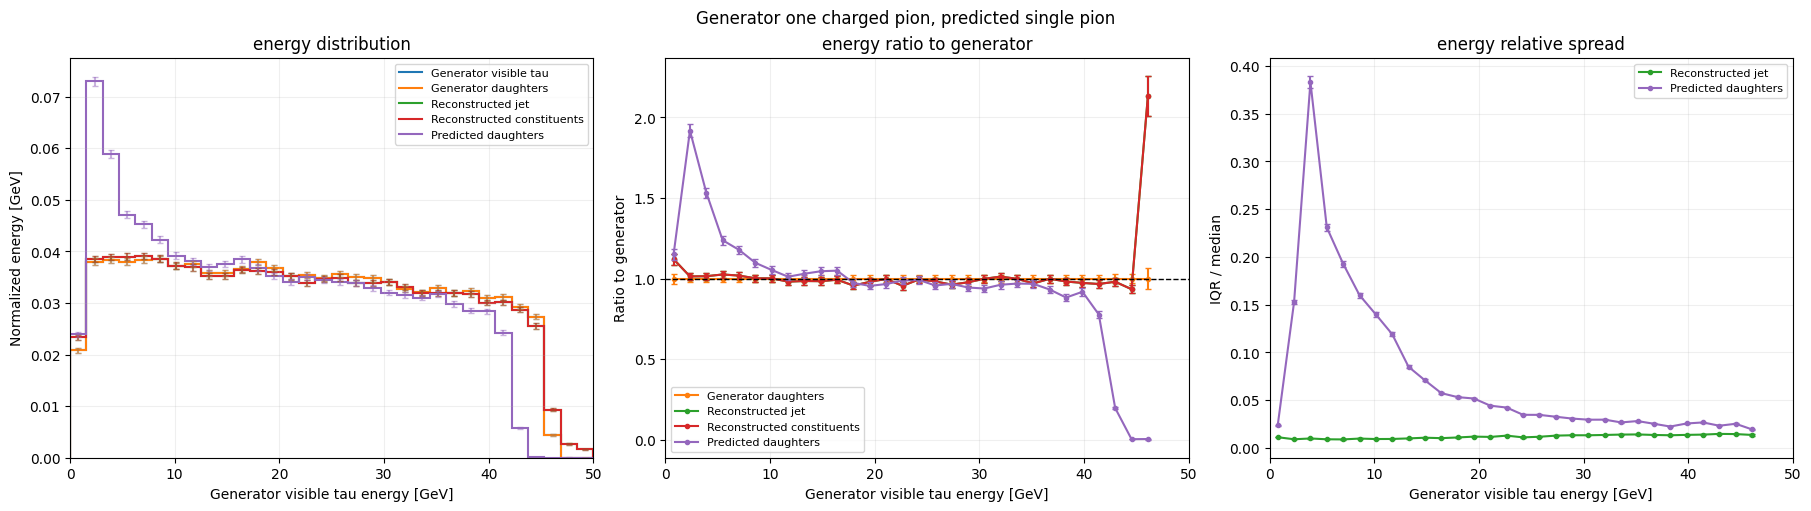

In [12]:
for selection_label, event_mask in event_selections.items():
    for quantity in quantity_ranges:
        plot_quantity(quantity, event_mask=event_mask, selection_label=selection_label)

In [13]:
def plot_correlations(quantity, event_mask=None, selection_label="Inclusive"):
    generator_values = source_quantity(
        "gen_jet_tau_p4", quantity, is_array=False, event_mask=event_mask
    )
    comparison_values = {
        "Reconstructed jet": source_quantity(
            "reco_jet_p4", quantity, is_array=False, event_mask=event_mask
        ),
        "Summed predicted daughters": source_quantity(
            "pred_tau_daughter_p4s", quantity, is_array=True, event_mask=event_mask
        ),
    }
    value_range = quantity_ranges[quantity]
    unit = f" [{quantity_units[quantity]}]" if quantity_units[quantity] else ""
    bins = np.linspace(*value_range, n_bins + 1)
    cmap = mpl.colormaps["magma_r"].copy()
    cmap.set_bad("white")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, (comparison_name, values) in zip(axes, comparison_values.items()):
        mask = np.isfinite(generator_values) & np.isfinite(values)
        counts, _, _ = np.histogram2d(generator_values[mask], values[mask], bins=(bins, bins))
        normalized_counts = np.divide(
            counts,
            counts.sum(axis=1, keepdims=True),
            out=np.zeros_like(counts),
            where=counts.sum(axis=1, keepdims=True) > 0,
        )
        normalized_counts = np.ma.masked_where(counts.T == 0, normalized_counts.T)
        image = ax.pcolormesh(bins, bins, normalized_counts, cmap=cmap, vmin=0, vmax=1)
        ax.set(
            title=f"Generator vs {comparison_name.lower()}",
            xlabel=f"Generator visible tau {quantity}{unit}",
            ylabel=f"{comparison_name} {quantity}{unit}",
            xlim=value_range,
            ylim=value_range,
        )
        fig.colorbar(image, ax=ax, label="Fraction per generator bin")
    fig.suptitle(f"{selection_label}: {quantity} migration matrices")
    plt.show()
    plt.close()

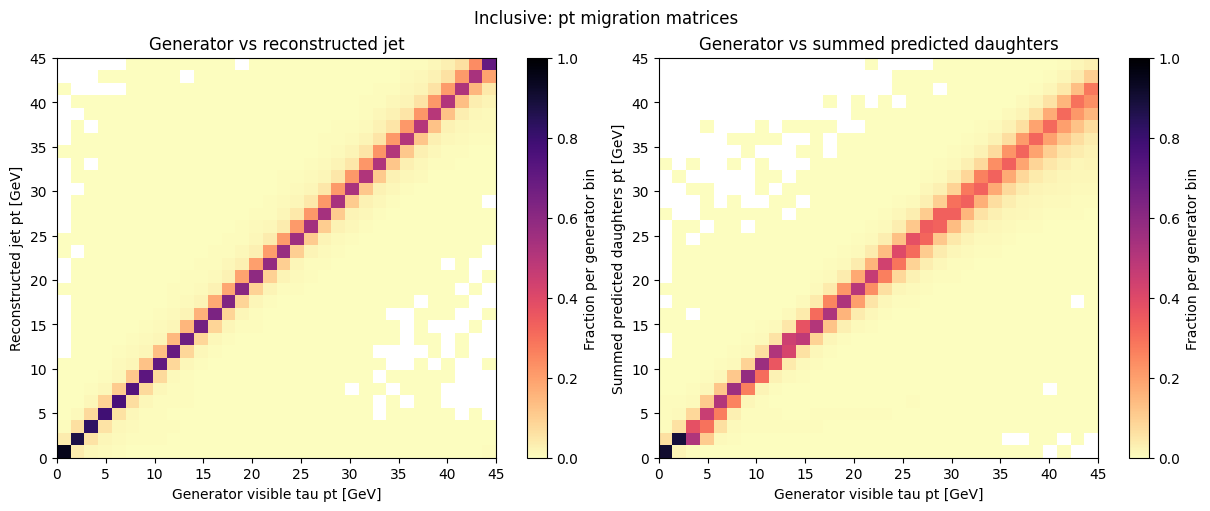

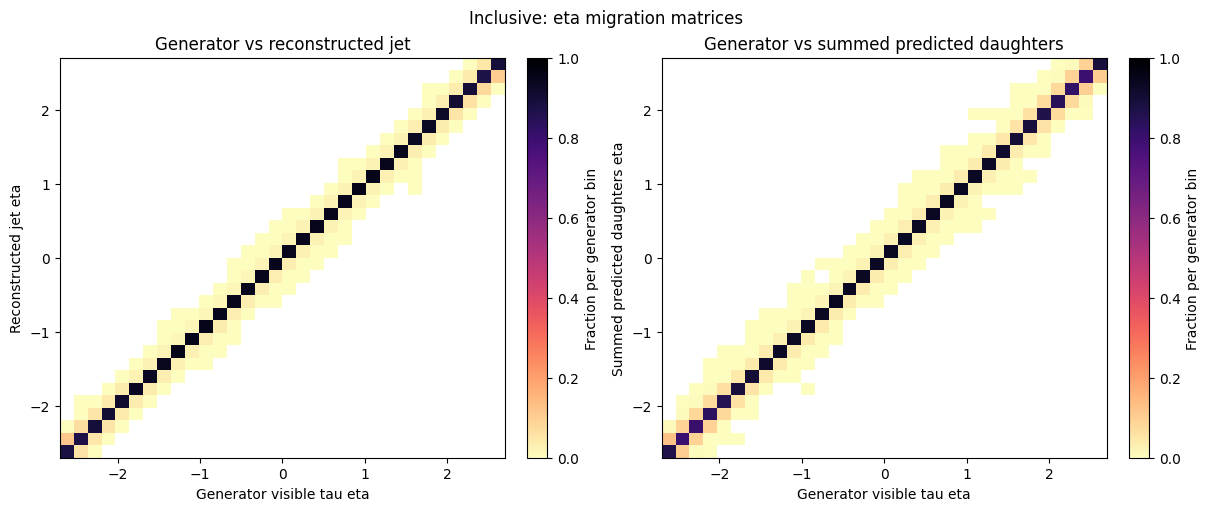

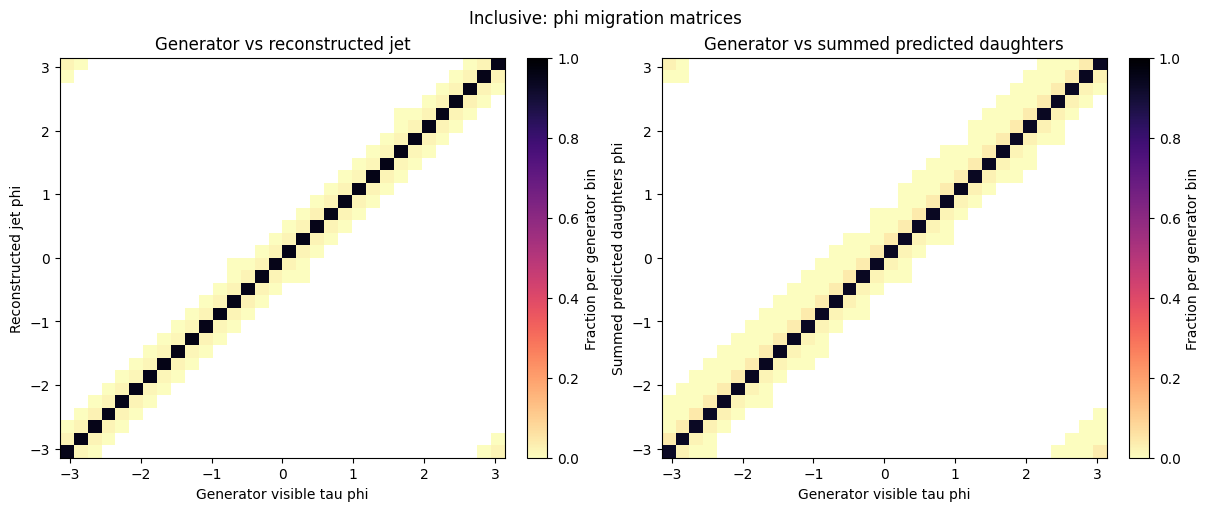

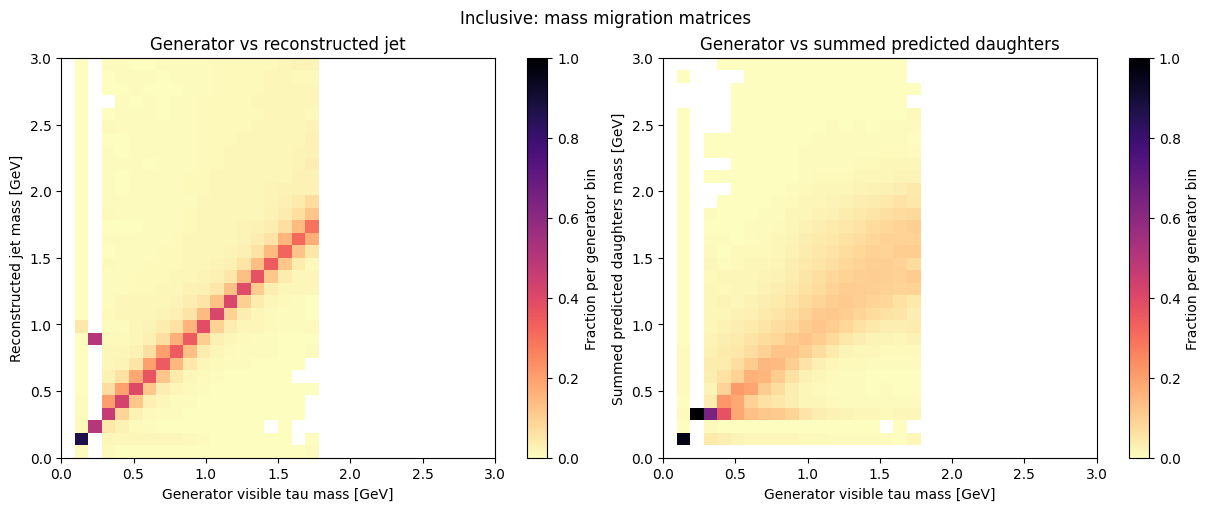

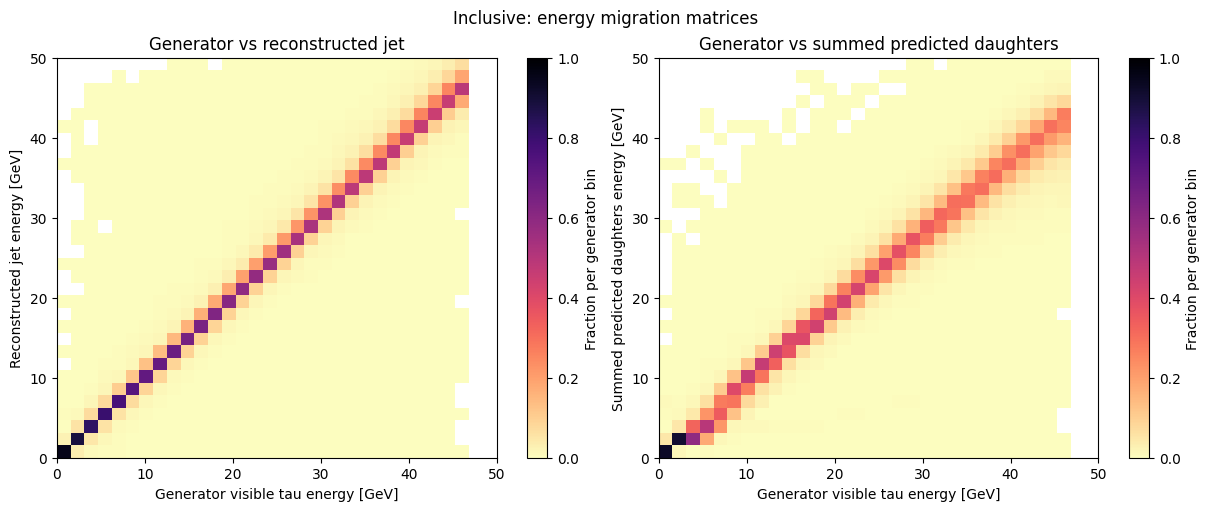

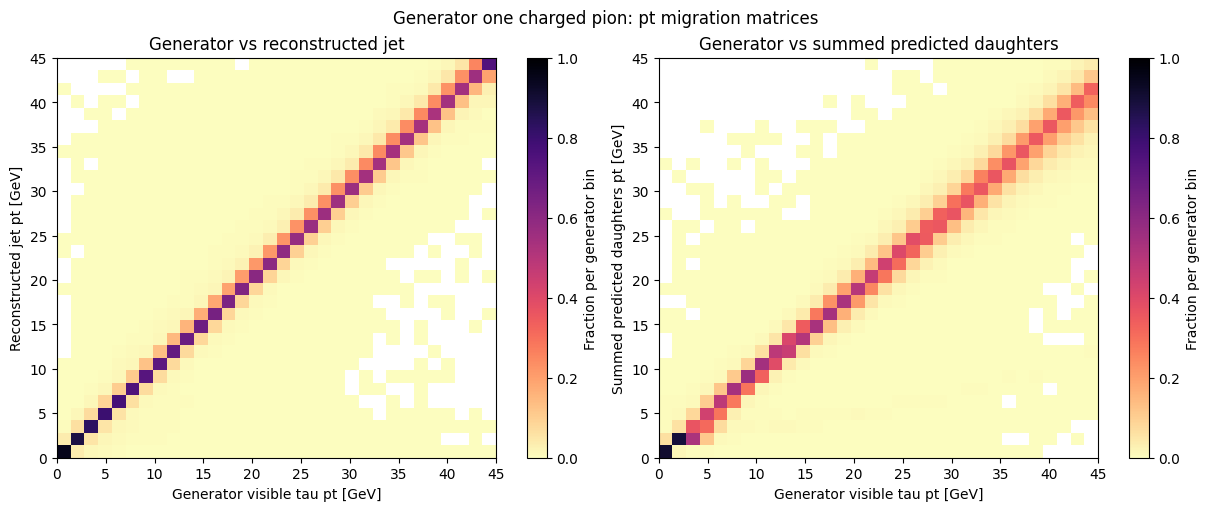

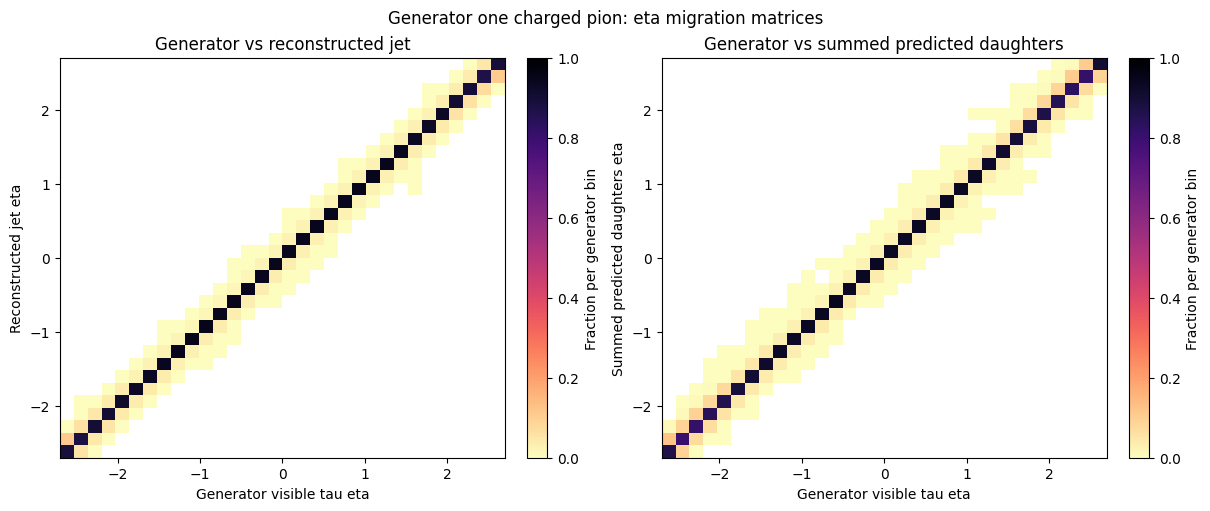

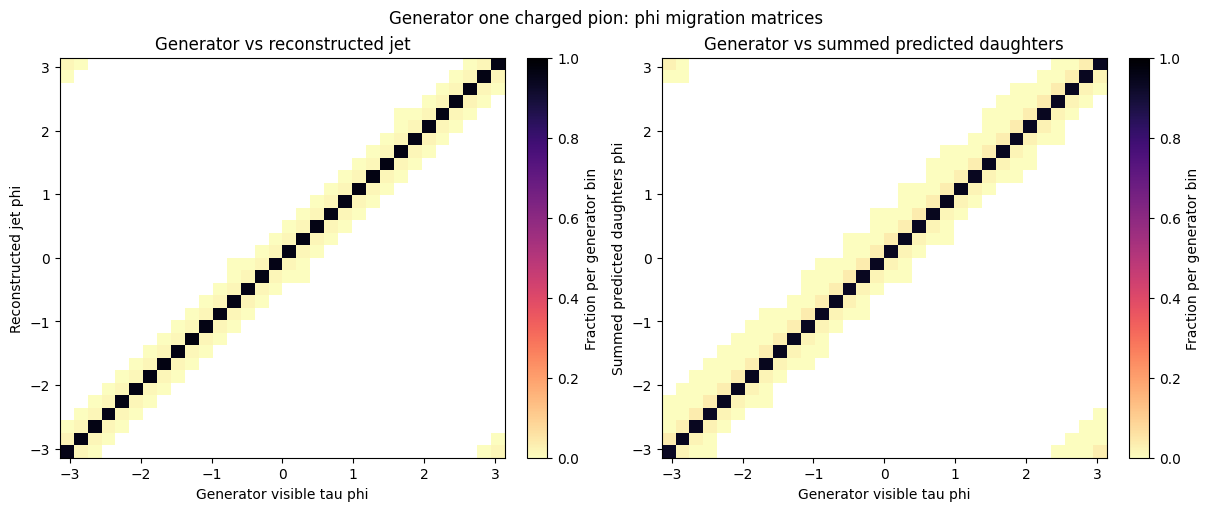

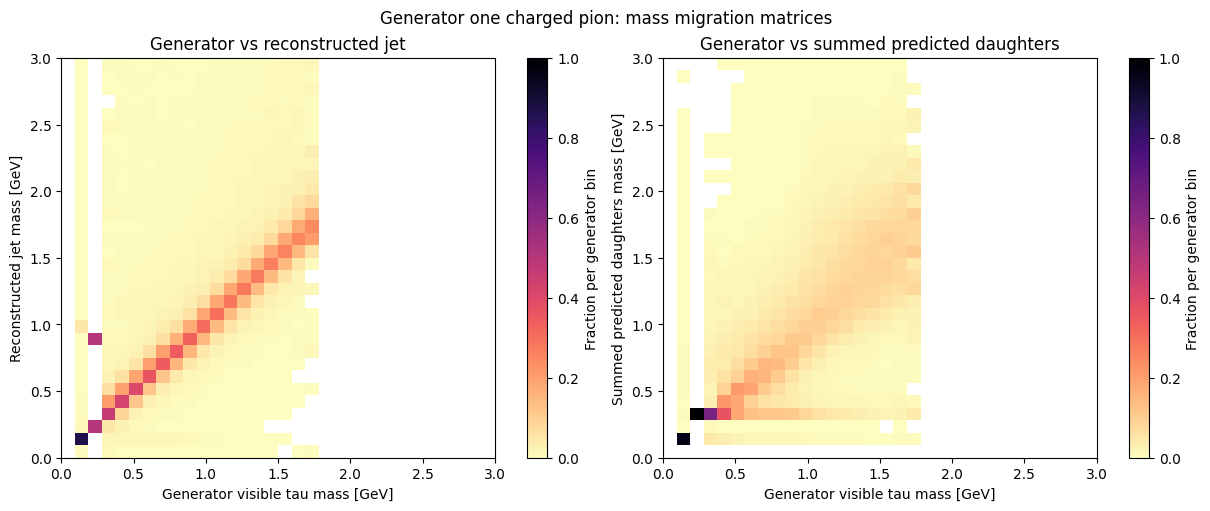

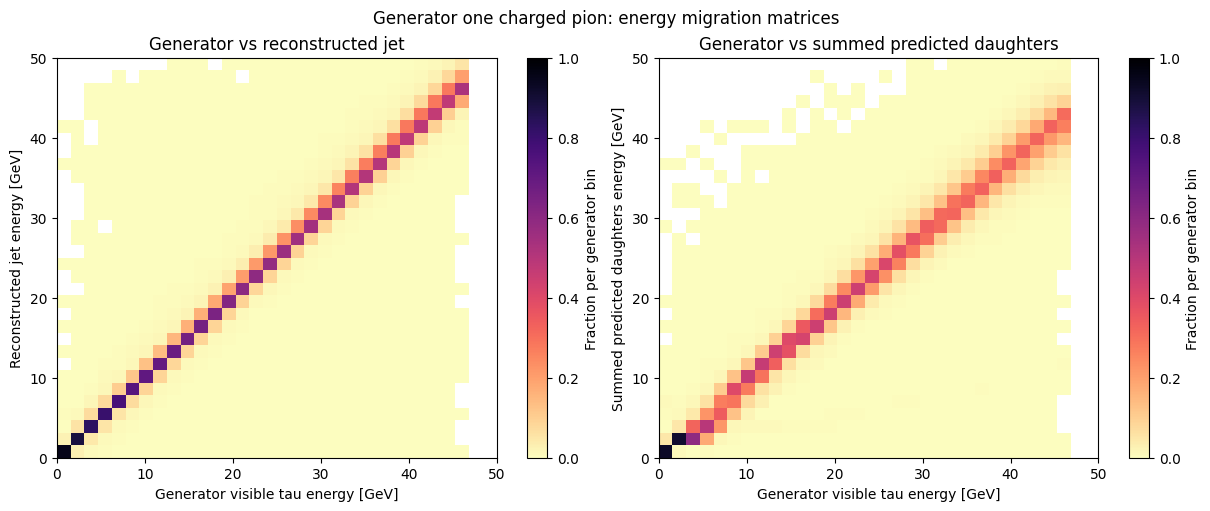

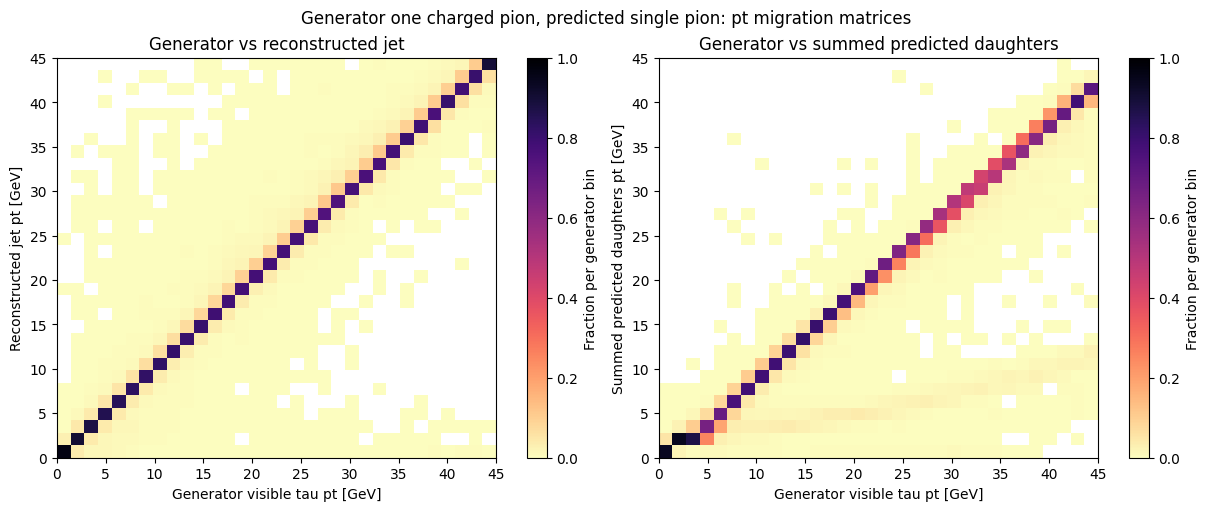

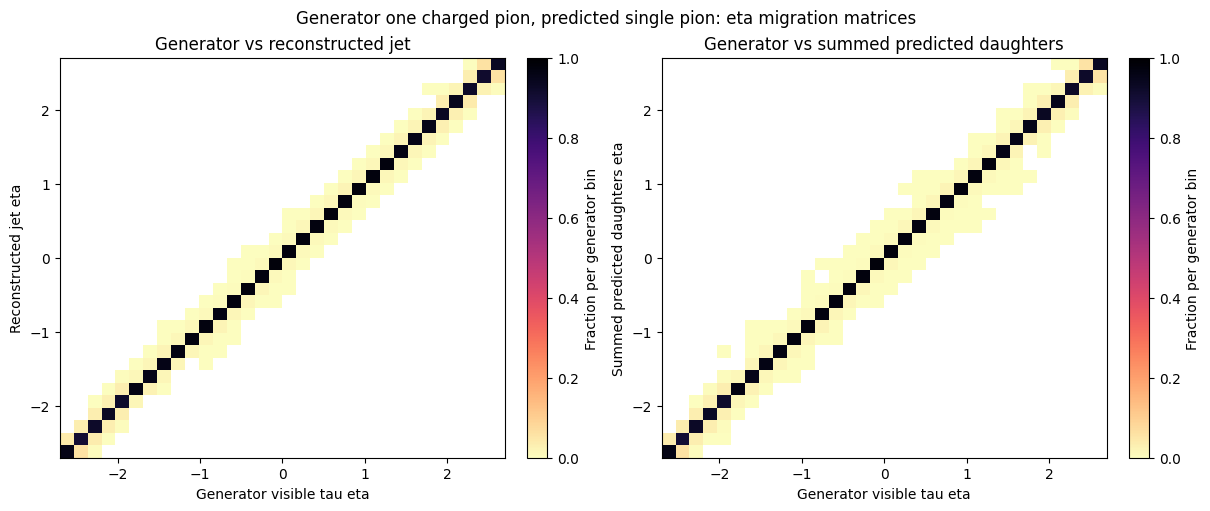

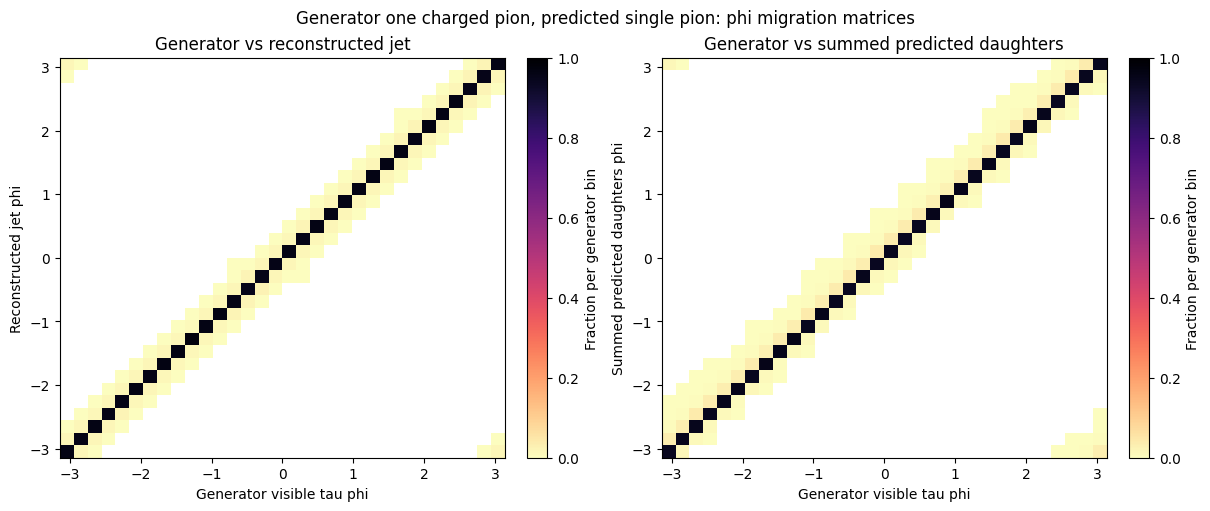

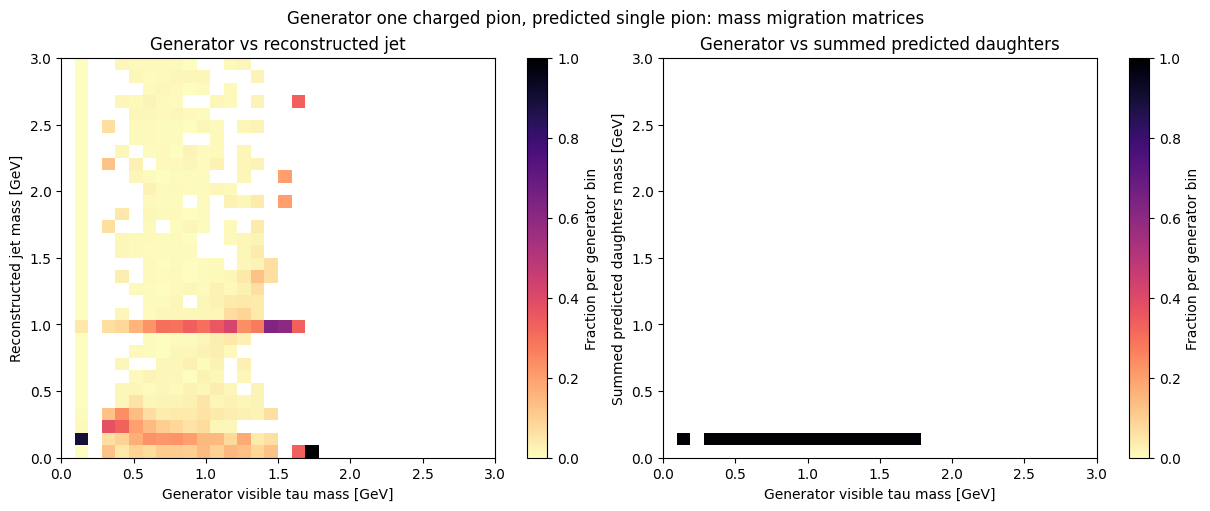

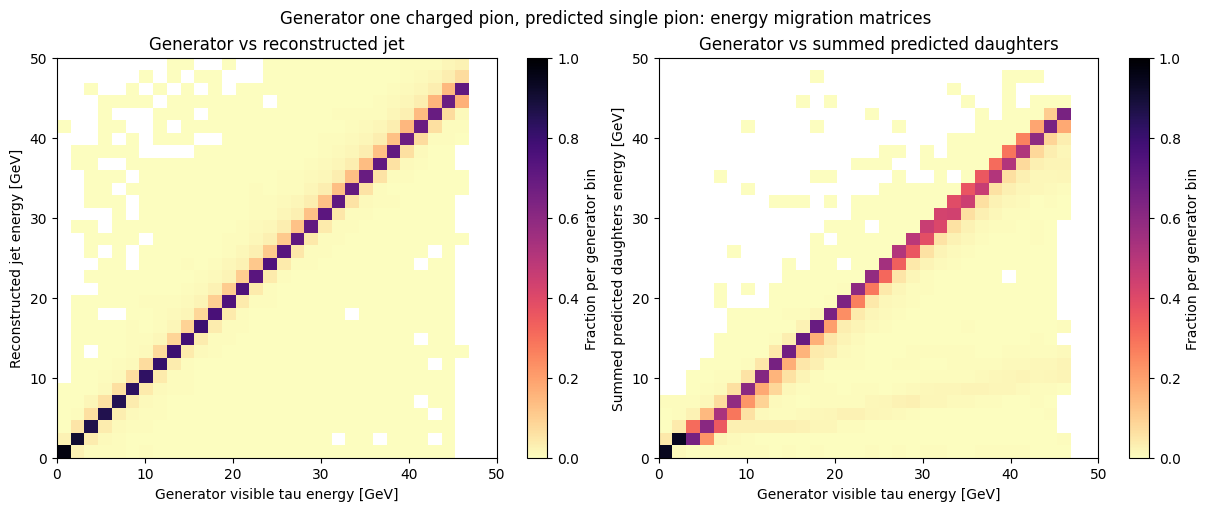

In [14]:
for selection_label, event_mask in event_selections.items():
    for quantity in quantity_ranges:
        plot_correlations(quantity, event_mask=event_mask, selection_label=selection_label)